# Machine Learning Exploratory Analysis

## Import Libraries 

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

## Import data 

In [3]:
ml_data = pd.read_csv("output/processed_variants_for_EDA.tsv", sep='\t', low_memory=False)
print(f"Imported {len(ml_data):,} variants for EDA.")

Imported 1,906 variants for EDA.


## Initial Data Inspection 

In [4]:
print(f"The ML data has {ml_data.shape[0]} rows and {ml_data.shape[1]} columns.")

The ML data has 1906 rows and 16 columns.


In [5]:
print("The columns in the data set have the following data types:")
print(ml_data.dtypes)

The columns in the data set have the following data types:
Hugo_Symbol              str
Consequence              str
Variant_Type             str
gnomAD_AF            float64
has_gnomAD_AF           bool
Polyphen_Score       float64
SIFT_Score           float64
In_Hotspot              bool
IN_DOMAIN               bool
n_protein_domains      int64
IN_FUNC_SITE            bool
n_func_sites           int64
ONCOGENIC                str
missing_Polyphen       int64
missing_SIFT           int64
target                 int64
dtype: object


In [6]:
print("The five first rows of the df:")
display(ml_data.head())


The five first rows of the df:


,Hugo_Symbol,Consequence,Variant_Type,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT,target
0,MAPK1,missense_variant,SNP,0.000000,False,1.000,0.01,False,True,1,False,0,Likely Neutral,0,0,0
1,BRCA1,missense_variant,SNP,0.000000,False,0.344,0.00,False,False,0,False,0,Oncogenic,0,0,1
2,BRCA1,missense_variant,SNP,0.000032,True,0.026,0.00,False,True,1,False,0,Oncogenic,0,0,1
3,TP53,missense_variant,SNP,0.000000,False,0.396,0.12,True,True,1,True,2,Oncogenic,0,0,1
4,TP53,missense_variant,SNP,0.000000,False,0.838,0.02,True,True,1,True,1,Oncogenic,0,0,1


In [7]:
print("The five last rows of the df:") 
display(ml_data.tail())

The five last rows of the df:


,Hugo_Symbol,Consequence,Variant_Type,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT,target
1901,BIRC3,missense_variant,SNP,0.0,False,0.223,0.03,False,True,1,False,0,Likely Neutral,0,0,0
1902,MED12,missense_variant,SNP,0.0,False,0.178,0.01,False,False,0,False,0,Oncogenic,0,0,1
1903,MED12,missense_variant,SNP,0.0,False,0.014,1.00,False,False,0,False,0,Oncogenic,0,0,1
1904,MED12,missense_variant,SNP,0.0,False,0.974,0.00,False,False,0,False,0,Oncogenic,0,0,1
1905,MED12,missense_variant,SNP,0.0,False,0.035,0.01,False,False,0,False,0,Oncogenic,0,0,1


In [8]:
print("Descriptive statistics on numeric columns in the df:")
print(ml_data.describe())

Descriptive statistics on numeric columns in the df:
         gnomAD_AF  Polyphen_Score   SIFT_Score  n_protein_domains  \
count  1906.000000     1510.000000  1510.000000        1906.000000   
mean      0.000004        0.689134     0.077132           0.628017   
std       0.000020        0.387168     0.176132           0.485628   
min       0.000000        0.000000     0.000000           0.000000   
25%       0.000000        0.323250     0.000000           0.000000   
50%       0.000000        0.935000     0.000000           1.000000   
75%       0.000000        0.998000     0.060000           1.000000   
max       0.000352        1.000000     1.000000           2.000000   

       n_func_sites  missing_Polyphen  missing_SIFT       target  
count   1906.000000       1906.000000   1906.000000  1906.000000  
mean       0.552466          0.207765      0.207765     0.550367  
std        0.591831          0.405814      0.405814     0.497587  
min        0.000000          0.000000      0.000

## Missing Value Analysis

In [9]:
print("Number of rows with missing values per feature (column):")
print(ml_data.isnull().sum())

Number of rows with missing values per feature (column):
Hugo_Symbol            0
Consequence            0
Variant_Type           0
gnomAD_AF              0
has_gnomAD_AF          0
Polyphen_Score       396
SIFT_Score           396
In_Hotspot             0
IN_DOMAIN              0
n_protein_domains      0
IN_FUNC_SITE           0
n_func_sites           0
ONCOGENIC              0
missing_Polyphen       0
missing_SIFT           0
target                 0
dtype: int64


Polyphen_Score and SIFT_Score each has 396 rows with missing values. 

## Target Variable Analysis

In [10]:
print("Variants per target class:")
print(ml_data.groupby("ONCOGENIC").size())

Variants per target class:
ONCOGENIC
Likely Neutral     857
Oncogenic         1049
dtype: int64


In [11]:
oncogenic = ml_data[ml_data["ONCOGENIC"] == "Oncogenic"]
neutral = ml_data[ml_data["ONCOGENIC"] == "Likely Neutral"]
print(f"{len(oncogenic)/len(ml_data)*100:.2f}% of the variants are Oncogenic.")
print(f"{len(neutral)/len(ml_data)*100:.2f}% of the variants are Likely Neutral")

55.04% of the variants are Oncogenic.
44.96% of the variants are Likely Neutral


## Gene Distribution Analysis

In [12]:
# Gene distribution by target class
pivot = (ml_data.groupby(["ONCOGENIC", "Hugo_Symbol"])
                .size()
                .reset_index(name="count")
                .pivot(index="Hugo_Symbol", columns="ONCOGENIC", values="count")
                .fillna(0))
print(pivot)

ONCOGENIC    Likely Neutral  Oncogenic
Hugo_Symbol                           
AKT1                    4.0        5.0
AKT2                    0.0        1.0
AKT3                    0.0        1.0
ALK                    14.0        3.0
AR                     16.0        4.0
...                     ...        ...
VAV1                    3.0        0.0
VHL                     2.0        4.0
WHSC1                   0.0        2.0
XPO1                    0.0        1.0
XRCC1                   2.0        0.0

[155 rows x 2 columns]


## Univariate Analysis 

### Numeric Feature Distributions

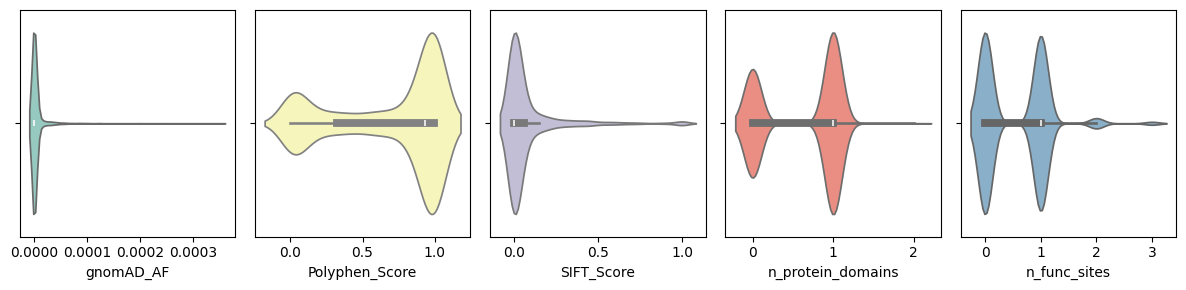

In [13]:
# visualize feature distributions 

wanted_indices = {3,5,6,9,11}

columns = [col for i, col in enumerate(ml_data.columns) if i in wanted_indices]

fig, axes = plt.subplots(1,5, figsize = (12,3)) 
axes = axes.flatten() 

colors = sns.color_palette('Set3', n_colors=len(columns)) 
for i, col in enumerate(columns):
    sns.violinplot(x=col, data=ml_data, ax=axes[i], 
color=colors[i])
plt.tight_layout()
plt.show()


### Binary Feature Distributions

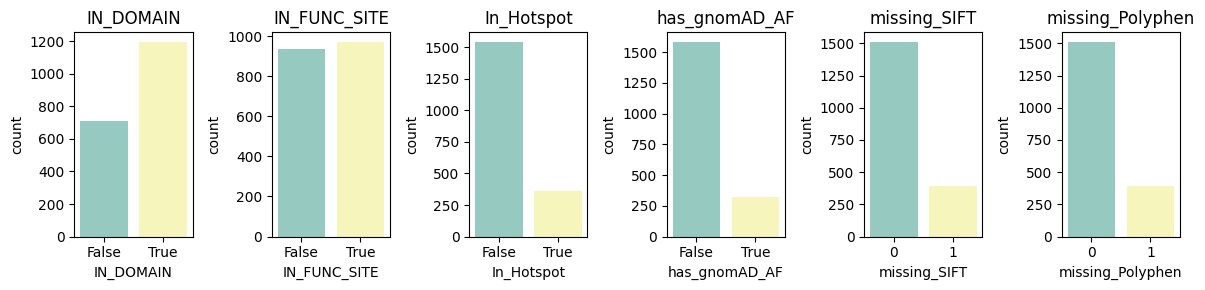

In [14]:
binary_cols = ["IN_DOMAIN", "IN_FUNC_SITE", "In_Hotspot", "has_gnomAD_AF", "missing_SIFT", "missing_Polyphen"]

fig, axes = plt.subplots(1, len(binary_cols), figsize=(12, 3))

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, data=ml_data, ax=axes[i], 
                  hue=col, palette="Set3", legend=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Categorical Feature Distributions

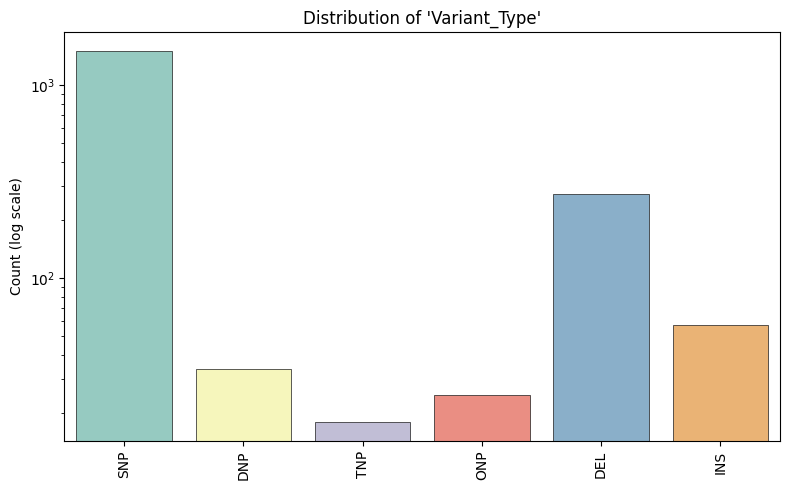

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=ml_data, x="Variant_Type", hue="Variant_Type",
              palette="Set3", legend=False, edgecolor="0.1", linewidth=0.5)
plt.title("Distribution of 'Variant_Type'")
plt.xlabel("")
plt.yscale("log")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


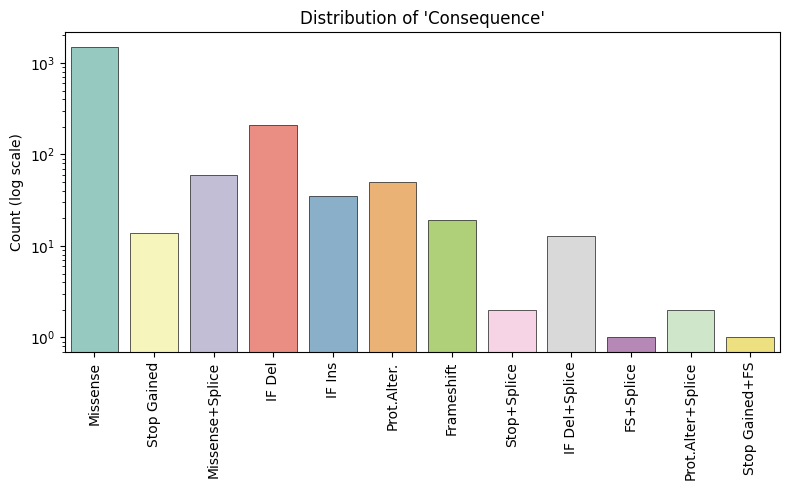

In [16]:
plt.figure(figsize=(8,5))

consequence_map = {
    "missense_variant"                          : "Missense",
    "stop_gained"                               : "Stop Gained",
    "inframe_deletion"                          : "IF Del",
    "inframe_insertion"                         : "IF Ins",
    "missense_variant,splice_region_variant"    : "Missense+Splice",
    "protein_altering_variant"                  : "Prot.Alter.",
    "frameshift_variant"                        : "Frameshift",
    "stop_gained,splice_region_variant"         : "Stop+Splice",
    "inframe_deletion,splice_region_variant"    : "IF Del+Splice",
    "frameshift_variant,splice_region_variant"  : "FS+Splice",
    "protein_altering_variant,splice_region_variant" : "Prot.Alter+Splice",
    "stop_gained,frameshift_variant"            : "Stop Gained+FS"
}

ml_data["Consequence_short"] = ml_data["Consequence"].map(consequence_map).fillna(ml_data["Consequence"])

sns.countplot(data=ml_data, x="Consequence_short", hue="Consequence_short",
              palette="Set3", legend=False, edgecolor="0.1", linewidth=0.5)
plt.title("Distribution of 'Consequence'")
plt.xlabel("")
plt.yscale("log")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

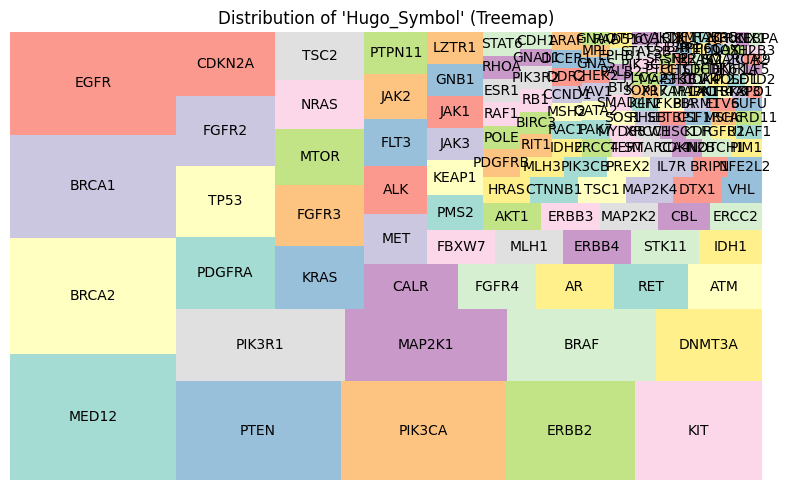

In [17]:
gene_counts = ml_data["Hugo_Symbol"].value_counts()

plt.figure(figsize=(8, 5))
squarify.plot(sizes=gene_counts.values,
              label=gene_counts.index,
              alpha=0.8, color=sns.color_palette("Set3", len(gene_counts)))
plt.title("Distribution of 'Hugo_Symbol' (Treemap)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Multivariate Analysis

### Correlation Heatmap (numeric features)

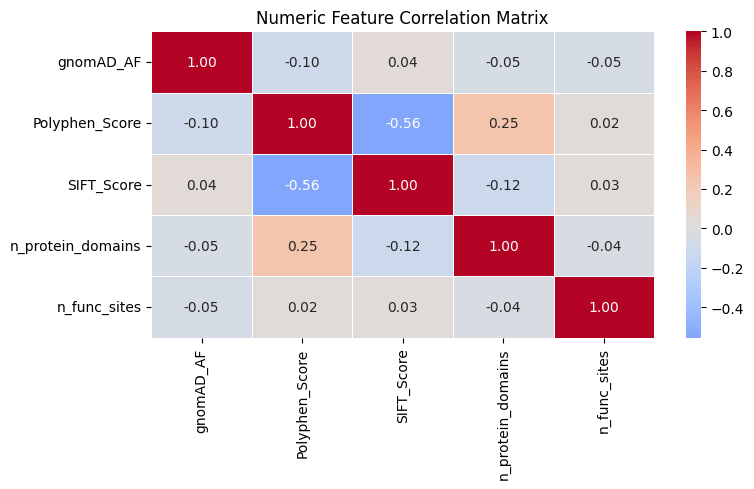

In [18]:
numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", 
                "n_protein_domains", "n_func_sites"]

plt.figure(figsize=(8,5)) 
sns.heatmap(ml_data[numeric_cols].corr(),
            annot=True, fmt=".2f", cmap="coolwarm",
            center=0, edgecolor="white", linewidths=0.5)
plt.title("Numeric Feature Correlation Matrix")

plt.tight_layout() 
plt.show() 


Positive correlation: Polyphen_Score and n_protein_domains 

Negative correlation: SIFT_Score and Polyphen_Score, SIFT_Score and n_protein_domains

### Numeric Features vs. Target 

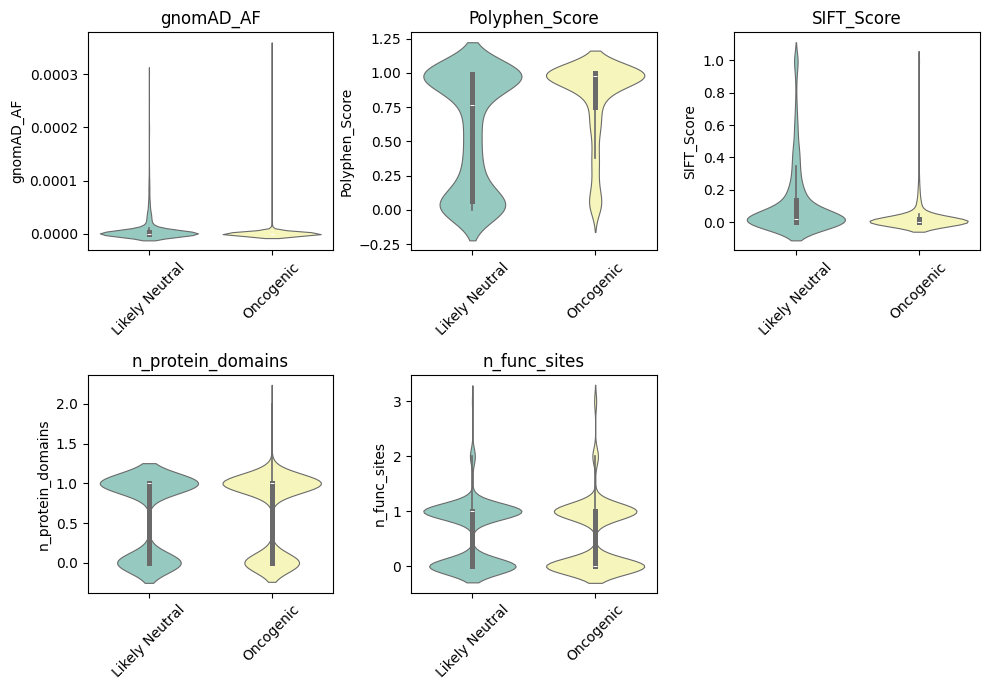

In [32]:
fig, axes = plt.subplots(2,3, figsize=(10,7)) 
axes = axes.flatten() 

numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", 
                "n_protein_domains", "n_func_sites"]

for i, col in enumerate(numeric_cols):
  sns.violinplot(data=ml_data, x="ONCOGENIC", y=col, 
              hue="ONCOGENIC", palette="Set3",
              legend=False, ax=axes[i], 
              linewidth=0.8) 
  axes[i].set_title(col) 
  axes[i].set_xlabel("") 
  axes[i].tick_params(axis="x", rotation=45) 

axes[-1].set_visible(False)
plt.tight_layout()
plt.show() 


### Categorical Features vs. Target 

In [ ]:
categorical_cols = ['has_gnomAD_AF','Consequence_short', 'Variant_Type', 
                    'In_Hotspot','In_Domain', 'IN_FUNC_SITE', 
                    'missing_Polyphen','missing_SIFT'
                    ]

fig, axes = plt.subplots(4,2, figsize=(8,5))
axes=axes.flatten

for i, col in enumerate(categorical_cols): 
  order = ml_data[col].value_counts().index 
  sns.countplot(data=ml_data, x=col, hue="ONCOGENIC",
                palette="Set3", ax=axes[i], order=order) 
  axes[i].set_title(col) 
  axes[i].set_xlabel("") 
  axes[i].tick_params(axis=x, rotation=45)
  axes[i].legend(title="ONCOGENIC", fontsize=8) 

for j in range(len(categorical_cols), len(axes)): 
  axes[j].set_visible(False) 

plt.tight_layout()
plt.show() 

### Pairplots (relationships between the numeric features) 

### Top Genes per Oncogenic Class 